In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install ultralytics opencv-python-headless pandas matplotlib seaborn pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.5 MB/s eta 0:00:00


In [ ]:
import zipfile
import os

# Path to the zip file
zip_path = "/content/drive/MyDrive/dataset/HelloDataset2.zip"

# Destination folder
extract_path = "/content/YOLO_Project"

# Make sure the destination directory exists
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed! Files are now in:", extract_path)

Extraction completed! Files are now in: /content/YOLO_Project


In [ ]:
# Import libraries and suppress warnings
import warnings
warnings.filterwarnings("ignore")
import os
import re
import glob
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from PIL import Image
import cv2
from ultralytics import YOLO
import IPython.display as display

# Define configuration settings
class Config:
    DEBUG_MODE = False
    DATA_FRACTION = 0.10 if DEBUG_MODE else 1.0
    RANDOM_SEED = 88
    DETECTION_CLASSES = ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask',
                         'NO-Safety Vest', 'Person', 'Safety Cone',
                         'Safety Vest', 'machinery', 'vehicle']
    TOTAL_CLASSES = len(DETECTION_CLASSES)
    TRAINING_EPOCHS = 3 if DEBUG_MODE else 100
    BATCH_SIZE = 16
    YOLO_BASE_MODEL = 'yolov8l'
    MODEL_WEIGHTS = f'{YOLO_BASE_MODEL}.pt'
    EXPERIMENT_NAME = f'ppe_detection_{TRAINING_EPOCHS}_epochs'
    OPTIMIZER_TYPE = 'auto'
    INITIAL_LR = 1e-3
    LR_REDUCTION_FACTOR = 0.01
    WEIGHT_DECAY_RATE = 5e-4
    DROPOUT_RATE = 0.025
    EARLY_STOP_PATIENCE = 25
    ENABLE_PROFILING = False
    LABEL_SMOOTH_FACTOR = 0.0
    DATASET_PATH = '/content/YOLO_Project/css-data'
    RESULTS_DIRECTORY = './'


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Generate and display data configuration file
config_dict = {
    'train': os.path.join(Config.DATASET_PATH, 'train'),
    'val': os.path.join(Config.DATASET_PATH, 'valid'),
    'test': os.path.join(Config.DATASET_PATH, 'test'),
    'nc': Config.TOTAL_CLASSES,
    'names': Config.DETECTION_CLASSES
}


# Define the checkpoint path dynamically
checkpoint_dir = os.path.join(Config.RESULTS_DIRECTORY, 'runs', 'detect', f'{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}', 'weights')
checkpoint_path = os.path.join(checkpoint_dir, 'last.pt')

# Create results directory if it doesn't exist
os.makedirs(Config.RESULTS_DIRECTORY, exist_ok=True)

# Write configuration to YAML
with open(os.path.join(Config.RESULTS_DIRECTORY, 'data_config.yaml'), 'w') as config_file:
    yaml.dump(config_dict, config_file)

# Load and display YAML content
def load_yaml_config(file_path):
    with open(file_path, 'r') as config_file:
        try:
            return yaml.safe_load(config_file)
        except yaml.YAMLError as error:
            print("Error loading YAML:", error)
            return None

def display_yaml_content(config_data):
    print(yaml.dump(config_data, default_flow_style=False))

yaml_file_path = os.path.join(Config.RESULTS_DIRECTORY, 'data_config.yaml')
loaded_config = load_yaml_config(yaml_file_path)
if loaded_config:
    display_yaml_content(loaded_config)

names:
- Hardhat
- Mask
- NO-Hardhat
- NO-Mask
- NO-Safety Vest
- Person
- Safety Cone
- Safety Vest
- machinery
- vehicle
nc: 10
test: /content/YOLO_Project/css-data/test
train: /content/YOLO_Project/css-data/train
val: /content/YOLO_Project/css-data/valid



In [ ]:
# Define functions for image visualization
def show_image(image_data, show_details=True, remove_axes=False):
    if isinstance(image_data, str):
        loaded_img = Image.open(image_data)
        plt.imshow(loaded_img)
    elif isinstance(image_data, np.ndarray):
        image_data = image_data[..., ::-1]  # BGR to RGB
        loaded_img = Image.fromarray(image_data)
        plt.imshow(loaded_img)
    else:
        raise ValueError("Unsupported image format")

    if show_details:
        print('Image Type:', type(loaded_img))
        print('Dimensions:', np.array(loaded_img).shape)

    if remove_axes:
        plt.axis('off')
    plt.show()

def visualize_random_images(directory_path, image_count=20, random_seed=Config.RANDOM_SEED):
    random.seed(random_seed)
    supported_extensions = ('.jpg', '.png', '.jpeg', '.gif')
    available_images = [f for f in os.listdir(directory_path) if f.lower().endswith(supported_extensions)]

    if len(available_images) < image_count:
        raise ValueError("Not enough images in the directory")

    chosen_images = random.sample(available_images, image_count)
    columns = 5
    rows = (image_count + columns - 1) // columns
    figure, axis_array = plt.subplots(rows, columns, figsize=(12, 8))

    for idx, img_file in enumerate(chosen_images):
        loaded_img = Image.open(os.path.join(directory_path, img_file))
        if rows == 1:
            current_ax = axis_array[idx % columns] if columns > 1 else axis_array
        else:
            current_ax = axis_array[idx // columns, idx % columns]
        current_ax.imshow(loaded_img)
        current_ax.axis('off')

    # Remove unused subplots
    for idx in range(image_count, rows * columns):
        if rows == 1 and columns > 1:
            figure.delaxes(axis_array[idx % columns])
        elif rows > 1:
            figure.delaxes(axis_array[idx // columns, idx % columns])

    plt.tight_layout()
    plt.show()

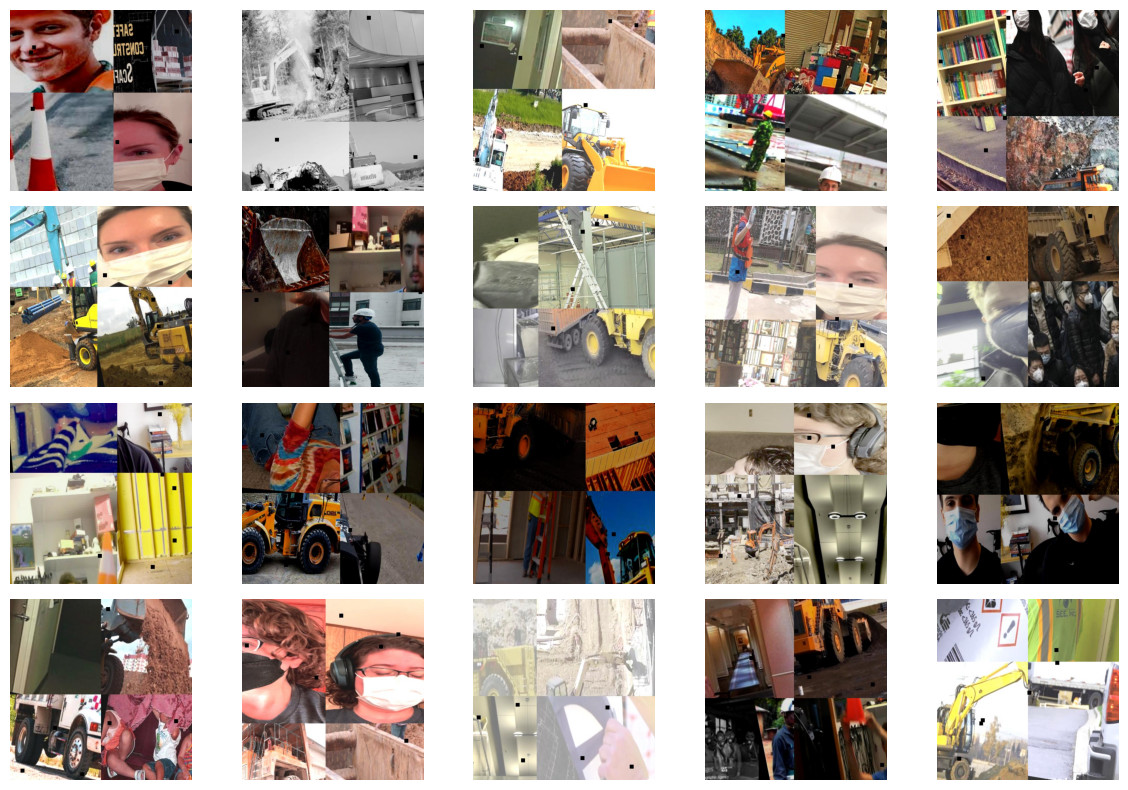

In [ ]:
# Display random training images
train_images_dir = os.path.join(Config.DATASET_PATH, 'train', 'images')
visualize_random_images(train_images_dir, image_count=20, random_seed=Config.RANDOM_SEED)

In [ ]:
# Function to extract image properties
def extract_image_details(image_file_path):
    loaded_img = cv2.imread(image_file_path)
    if loaded_img is None:
        raise ValueError("Failed to load image")
    return {
        "width": loaded_img.shape[1],
        "height": loaded_img.shape[0],
        "channels": loaded_img.shape[2] if len(loaded_img.shape) == 3 else 1,
        "data_type": loaded_img.dtype,
    }

# Select and analyze a random training image
example_image_path = os.path.join(Config.DATASET_PATH, 'train', 'images',
                                  random.choice(os.listdir(os.path.join(Config.DATASET_PATH, 'train', 'images'))))
img_properties = extract_image_details(example_image_path)
print(img_properties)

{'width': 640, 'height': 640, 'channels': 3, 'data_type': dtype('uint8')}


  Dataset Mode  Hardhat  Mask  NO-Hardhat  NO-Mask  NO-Safety Vest  Person  \
0        train     1314  1096        1380     1531            1864    2526   
1        valid       42    19          37       44              56      84   
2         test       30    16          25       30              36      59   

   Safety Cone  Safety Vest  machinery  vehicle  Total Samples  
0          631         1319       2101      744           2605  
1           13           28         26       16            114  
2            8           22         22       15             82  


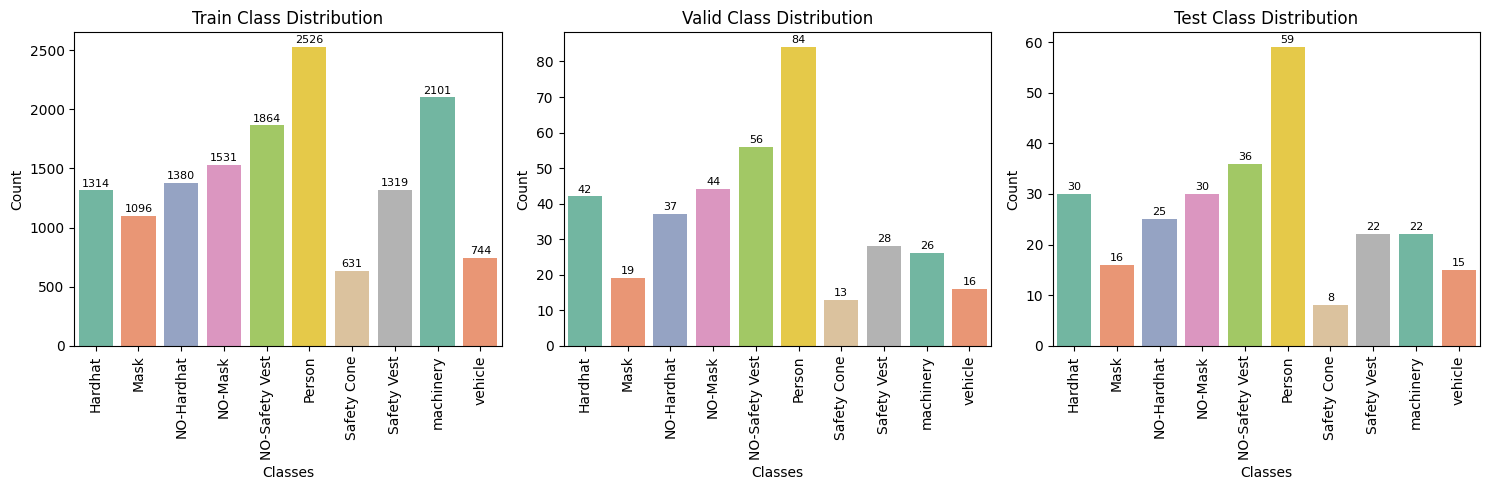

In [ ]:
# Compute and visualize dataset statistics
class_mapping = {str(idx): Config.DETECTION_CLASSES[idx] for idx in range(Config.TOTAL_CLASSES)}
mode_statistics = {}
dataset_sizes = {}
metrics_list = []

for dataset_mode in ['train', 'valid', 'test']:
    class_counts = {Config.DETECTION_CLASSES[idx]: 0 for idx in range(Config.TOTAL_CLASSES)}
    labels_dir = os.path.join(Config.DATASET_PATH, dataset_mode, 'labels')
    for label_file in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, label_file)) as file_content:
            label_lines = file_content.readlines()
            for unique_class in set([line.split()[0] for line in label_lines]):
                class_counts[class_mapping[unique_class]] += 1
    dataset_sizes[dataset_mode] = len(os.listdir(labels_dir))
    mode_statistics[dataset_mode] = class_counts
    metrics_list.append({'Dataset Mode': dataset_mode, **class_counts, 'Total Samples': dataset_sizes[dataset_mode]})

stats_dataframe = pd.DataFrame(metrics_list)
print(stats_dataframe)

# Plot class distribution
figure, axis_array = plt.subplots(1, 3, figsize=(15, 5))
for idx, dataset_mode in enumerate(['train', 'valid', 'test']):
    sns.barplot(
        data=stats_dataframe[stats_dataframe['Dataset Mode'] == dataset_mode].drop(columns=['Dataset Mode', 'Total Samples']),
        orient='v',
        ax=axis_array[idx],
        palette='Set2'
    )
    axis_array[idx].set_title(f'{dataset_mode.capitalize()} Class Distribution')
    axis_array[idx].set_xlabel('Classes')
    axis_array[idx].set_ylabel('Count')
    axis_array[idx].tick_params(axis='x', rotation=90)
    for bar_patch in axis_array[idx].patches:
        axis_array[idx].annotate(f"{int(bar_patch.get_height())}",
                                 (bar_patch.get_x() + bar_patch.get_width() / 2., bar_patch.get_height()),
                                 ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                                 textcoords='offset points')
plt.tight_layout()
plt.show()

In [ ]:
# Check image dimensions across datasets
for dataset_mode in ['train', 'valid', 'test']:
    print(f'\nImage sizes in {dataset_mode} dataset:')
    previous_size = None
    images_dir = os.path.join(Config.DATASET_PATH, dataset_mode, 'images')
    for img_file in glob.glob(os.path.join(images_dir, '*')):
        loaded_img = Image.open(img_file)
        if loaded_img.size != previous_size:
            print(f'{loaded_img.size}')
            previous_size = loaded_img.size


Image sizes in train dataset:
(640, 640)

Image sizes in valid dataset:
(640, 640)

Image sizes in test dataset:
(640, 640)


Using device: 0

image 1/1 /content/YOLO_Project/css-data/train/images/video_CDC-YOUTUBE_mp4-50_jpg.rf.cb32d15d49f5f5a43a828b26ef50c6f9.jpg: 640x640 2 persons, 63.0ms
Speed: 6.4ms preprocess, 63.0ms inference, 353.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
1 label saved to /content/runs/detect/predict/labels
Image Type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Dimensions: (640, 640, 3)


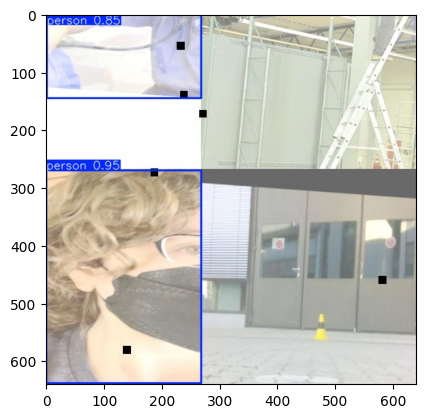

In [ ]:
# Load YOLO model and perform initial prediction
import torch
from ultralytics import YOLO

computing_device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Using device: {computing_device}")

detection_model = YOLO(Config.MODEL_WEIGHTS)
inference_results = detection_model.predict(
    source=example_image_path,
    classes=[0],  # Hardhat class
    conf=0.40,
    device=computing_device,
    imgsz=(img_properties['height'], img_properties['width']),
    save=True,
    save_txt=True,
    save_conf=True,
    exist_ok=True,
)

# Display prediction result
inference_filename = example_image_path.split('/')[-1]
show_image(f'runs/detect/predict/{inference_filename}')

In [ ]:
# Display model configuration details
print('Model:', Config.MODEL_WEIGHTS)
print('Epochs:', Config.TRAINING_EPOCHS)
print('Batch Size:', Config.BATCH_SIZE)

Model: yolov8l.pt
Epochs: 100
Batch Size: 16


In [ ]:
# Cell 11: Train the YOLO model (resuming from checkpoint if available)
if os.path.exists(checkpoint_path):
    print(f"Resuming training from checkpoint: {checkpoint_path}")
    detection_model = YOLO(checkpoint_path)
    resume_training = True
else:
    print("No checkpoint found. Starting training from initial weights.")
    detection_model = YOLO(Config.MODEL_WEIGHTS)
    resume_training = False
    # Ensure the weights directory exists for new runs
    os.makedirs(checkpoint_dir, exist_ok=True)

detection_model.train(
    data=os.path.join(Config.RESULTS_DIRECTORY, 'data_config.yaml'),
    task='detect',
    imgsz=(img_properties['height'], img_properties['width']),
    epochs=Config.TRAINING_EPOCHS,
    batch=Config.BATCH_SIZE,
    optimizer=Config.OPTIMIZER_TYPE,
    lr0=Config.INITIAL_LR,
    lrf=Config.LR_REDUCTION_FACTOR,
    weight_decay=Config.WEIGHT_DECAY_RATE,
    dropout=Config.DROPOUT_RATE,
    fraction=Config.DATA_FRACTION,
    patience=Config.EARLY_STOP_PATIENCE,
    profile=Config.ENABLE_PROFILING,
    name=f'{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}',
    seed=Config.RANDOM_SEED,
    val=True,
    amp=True,
    exist_ok=True,
    resume=resume_training,
    device=computing_device,
    verbose=False,
)

No checkpoint found. Starting training from initial weights.
Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.025, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=(640, 640), int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8l_ppe_detection_100_epochs, nbs=64, nms=False, opset=None, optimize=False,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b86dcd94470>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [ ]:
# Run validation on the test dataset
metrics = detection_model.val(
    data="/content/YOLO_Project/css-data/data_config.yaml",  # same yaml used in training
    split="test",   # evaluate on test set
    imgsz=(img_properties['height'], img_properties['width']),
    batch=Config.BATCH_SIZE,
    device=computing_device,
    save_json=True,    # saves COCO-style JSON
    save_hybrid=True,  # saves predictions for analysis
    conf=0.25          # confidence threshold
)


WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
WARNING ⚠️ updating to 'imgsz=640'. 'train' and 'val' imgsz must be an integer, while 'predict' and 'export' imgsz may be a [h, w] list or an integer, i.e. 'yolo export imgsz=640,480' or 'yolo export imgsz=640'
Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 24.0±11.6 MB/s, size: 45.0 KB)
val: Scanning /content/YOLO_Project/css-data/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 475.6it/s 0.2s
val: New cache created: /content/YOLO_Project/css-data/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 0.9it/s 6.4s
                   all         82        760      0.954      0.787      0.878      0.664
Speed: 5.0ms preprocess, 39.7ms inference, 0.0ms loss, 7.9ms postprocess per image
Saving /content/runs/detect/yolov8l_ppe_detec

In [ ]:
detection_model.export(
    format="onnx",
    imgsz=(int(img_properties["height"]), int(img_properties["width"])),  # ensure integers
    half=False,      # FP16 disabled
    int8=False,      # INT8 quantization disabled
    simplify=False,  # ONNX simplification disabled
    nms=False        # export raw model without NMS
)


Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 112 layers, 43,614,318 parameters, 0 gradients, 164.9 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (83.6 MB)

ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: export success ✅ 12.1s, saved as '/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx' (166.6 MB)

Export complete (17.6s)
Results saved to /content/runs/detect/yolov8l_ppe_detection_100_epochs/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx imgsz=640 data=./data_config.yaml  
Visualize:       https://netron.app


'/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx'

In [ ]:
# Display training result images
outcome_images = [
    path for path in glob.glob(f'{Config.RESULTS_DIRECTORY}runs/detect/{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}/*.png') +
    glob.glob(f'{Config.RESULTS_DIRECTORY}runs/detect/{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}/*.jpg')
    if 'batch' not in path
]

for image_path in sorted(outcome_images):
    print(image_path)
    show_image(image_path, show_details=False, remove_axes=True)
    print('\n')

In [ ]:
# Load and display training logs
logs_df = pd.read_csv(f'{Config.RESULTS_DIRECTORY}runs/detect/{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}/results.csv')
logs_df = logs_df.rename(columns=lambda col: col.strip())
logs_df.to_csv(f'{Config.RESULTS_DIRECTORY}training_logs.csv', index=False)
print(logs_df)

# Show best metrics
print('*' * 50)
print('\nBest Training Box Loss:', logs_df['train/box_loss'].min(),
      'on epoch:', logs_df['train/box_loss'].argmin() + 1)
print('Best Validation Box Loss:', logs_df['val/box_loss'].min(),
      'on epoch:', logs_df['val/box_loss'].argmin() + 1)
print('=' * 50)
print('\nBest Training Cls Loss:', logs_df['train/cls_loss'].min(),
      'on epoch:', logs_df['train/cls_loss'].argmin() + 1)
print('Best Validation Cls Loss:', logs_df['val/cls_loss'].min(),
      'on epoch:', logs_df['val/cls_loss'].argmin() + 1)
print('=' * 50)
print('\nBest Training DFL Loss:', logs_df['train/dfl_loss'].min(),
      'on epoch:', logs_df['train/dfl_loss'].argmin() + 1)
print('Best Validation DFL Loss:', logs_df['val/dfl_loss'].min(),
      'on epoch:', logs_df['val/dfl_loss'].argmin() + 1)

    epoch       time  train/box_loss  train/cls_loss  train/dfl_loss  \
0       1    137.622         1.25573         1.75753         1.46241   
1       2    274.690         1.25510         1.52560         1.45364   
2       3    411.048         1.27780         1.55480         1.46841   
3       4    545.684         1.23246         1.48101         1.44119   
4       5    679.907         1.18724         1.37331         1.40513   
..    ...        ...             ...             ...             ...   
95     96  12939.000         0.44920         0.26730         0.90821   
96     97  13076.000         0.44056         0.26603         0.90619   
97     98  13213.300         0.43599         0.26098         0.90252   
98     99  13350.400         0.42887         0.25966         0.90122   
99    100  13488.800         0.42669         0.25918         0.90059   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0                0.58631            0.45145           0.46668   
1    

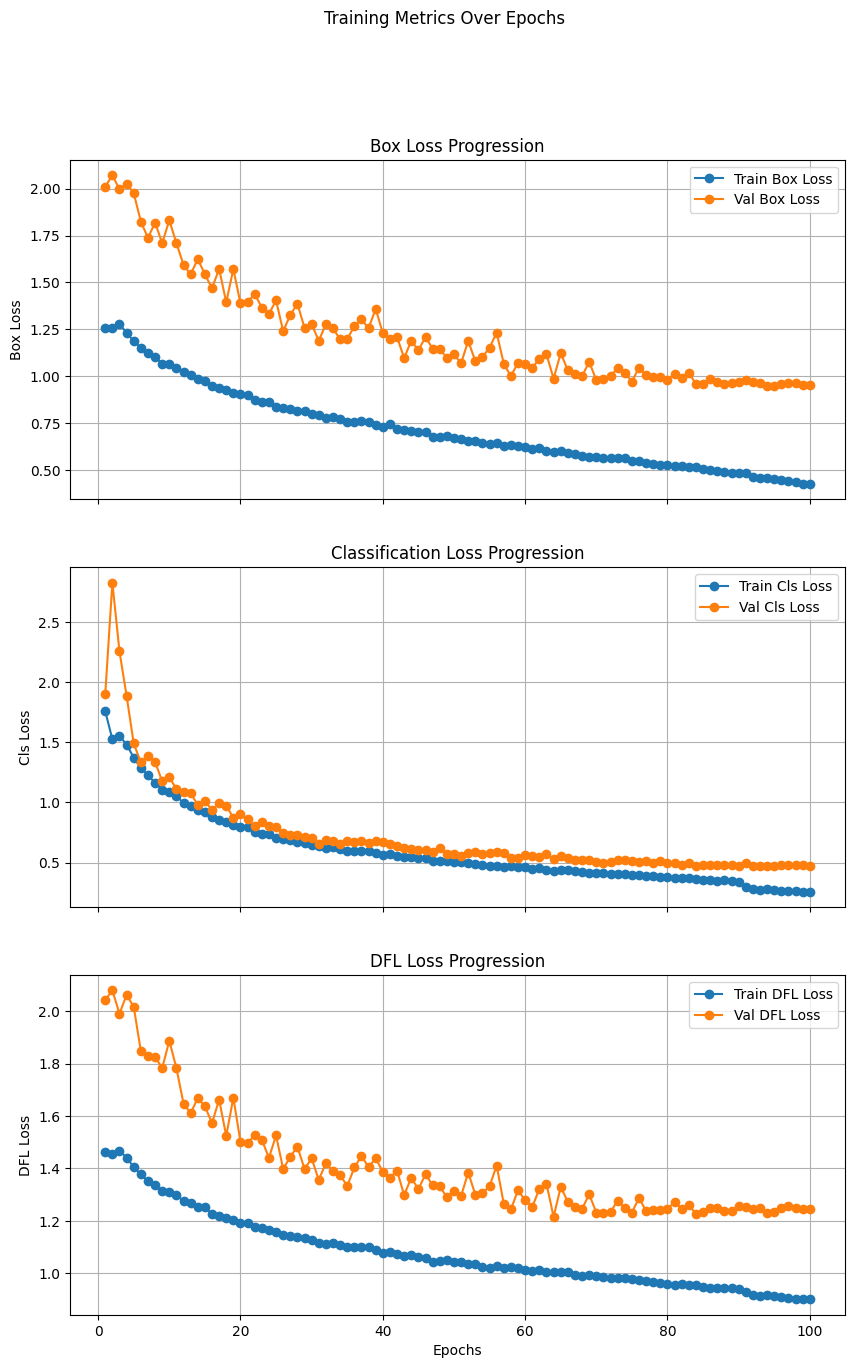

In [ ]:
# Plot training metrics
figure, (axis1, axis2, axis3) = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# Box Loss Plot
axis1.set_title('Box Loss Progression')
axis1.plot(logs_df['epoch'], logs_df['train/box_loss'], label='Train Box Loss', marker='o', linestyle='-')
axis1.plot(logs_df['epoch'], logs_df['val/box_loss'], label='Val Box Loss', marker='o', linestyle='-')
axis1.set_ylabel('Box Loss')
axis1.legend()
axis1.grid(True)

# Cls Loss Plot
axis2.set_title('Classification Loss Progression')
axis2.plot(logs_df['epoch'], logs_df['train/cls_loss'], label='Train Cls Loss', marker='o', linestyle='-')
axis2.plot(logs_df['epoch'], logs_df['val/cls_loss'], label='Val Cls Loss', marker='o', linestyle='-')
axis2.set_ylabel('Cls Loss')
axis2.legend()
axis2.grid(True)

# DFL Loss Plot
axis3.set_title('DFL Loss Progression')
axis3.plot(logs_df['epoch'], logs_df['train/dfl_loss'], label='Train DFL Loss', marker='o', linestyle='-')
axis3.plot(logs_df['epoch'], logs_df['val/dfl_loss'], label='Val DFL Loss', marker='o', linestyle='-')
axis3.set_xlabel('Epochs')
axis3.set_ylabel('DFL Loss')
axis3.legend()
axis3.grid(True)

plt.suptitle('Training Metrics Over Epochs')
plt.show()

Number of validation images: 6
./runs/detect/yolov8l_ppe_detection_100_epochs/val_batch2_pred.jpg


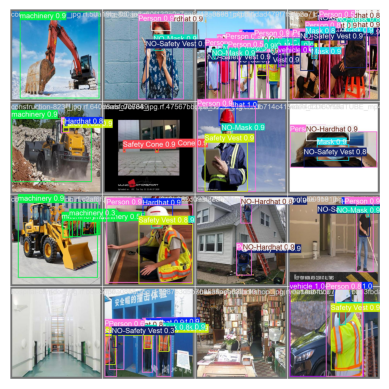

In [ ]:
# Display validation result images
val_outcome_paths = [
    path for path in glob.glob(f'{Config.RESULTS_DIRECTORY}runs/detect/{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}/*.png') +
    glob.glob(f'{Config.RESULTS_DIRECTORY}runs/detect/{Config.YOLO_BASE_MODEL}_{Config.EXPERIMENT_NAME}/*.jpg')
    if 'val_batch' in path
]

print(f'Number of validation images: {len(val_outcome_paths)}')
if len(val_outcome_paths) >= 1:
    random_val_image = random.choice(val_outcome_paths)
    print(random_val_image)
    show_image(random_val_image, show_details=False, remove_axes=True)

In [ ]:
# when exporting from Ultralytics (recommended)
detection_model.export(format='onnx', imgsz=(640,640), nms=True)


Ultralytics 8.3.202 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 112 layers, 43,614,318 parameters, 0 gradients, 164.9 GFLOPs

PyTorch: starting from '/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (83.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 12.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.0 opset 19...
ONNX: slimming with onnxslim 0.1.68...
ONNX: export success ✅ 31.5s, saved as '/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx' (166.7 MB)

Export complete (37.0s)
Results saved to /content/runs/detect/yolov8l_ppe_detection_100_epochs/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolov8l_ppe_detection_

'/content/runs/detect/yolov8l_ppe_detection_100_epochs/weights/best.onnx'

In [ ]:
import shutil
import os

# List of items to move
items_to_move = [
    "YOLO_Project",
    "runs",
    "data_config.yaml",
    "training_logs.csv",
    "yolov11n.pt",
    "yolov8l.pt",
    "yolo11n.pt",
]

# Create destination folder
collect_folder = "YOLO_All"
os.makedirs(collect_folder, exist_ok=True)

# Move files and folders
for item in items_to_move:
    if os.path.exists(item):
        dest = os.path.join(collect_folder, os.path.basename(item))
        shutil.move(item, dest)  # <-- MOVE instead of copy

print("✅ All files moved into YOLO_All/")


✅ All files moved into YOLO_All/


In [ ]:
import shutil

# Create zip from the collected folder
shutil.make_archive("YOLO_Project_Full", 'zip', "YOLO_All")

print("✅ Zipped as YOLO_Project_Full.zip")


✅ Zipped as YOLO_Project_Full.zip


In [ ]:
from google.colab import files

# Download the zip file
files.download("YOLO_Project_Full.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>